In [1]:
## Visualize Cross sections

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import cartopy.crs as crs
from cartopy.feature import NaturalEarthFeature
from netCDF4 import Dataset

from wrf import to_np, getvar, CoordPair, vertcross

#for plotting a two-dimensional field
from matplotlib.cm import get_cmap
from mpl_toolkits.basemap import Basemap
from wrf import to_np, getvar, smooth2d, get_basemap, latlon_coords

#to get a list of the files in the folder
import glob 

## General Goals

Drawing from visuals listed in the wrf pythong examples, want to get some visual looks at wind speed and potentially pressure from cross sections

I am not sure how exactly to choose the cross sectional locations or the times, but thinking we can pull a few time windows and a few cross sections and get a sense for things that way

Page to reference: https://wrf-python.readthedocs.io/en/latest/plot.html#cross-section-with-mountains

In [10]:
#d02_2016_names = glob.glob("../../01Data/Houston_MarineHeatWave_2016/wrfout_MarineHeatWave.d02.*")
#d02_2017_names = glob.glob("../../01Data/Houston_MarineHeatWave_2017/wrfout_MarineHeatWave.d02.*")
d02_2017_climavg_names  = glob.glob("../../01Data/Houston_MarineHeatWave_2017_w16SST/wrfout_MarineHeatWave.d02.*")

#ncfile = Dataset(d02_2016_names[19])
#ncfile = Dataset(d02_2017_names[19])
ncfile = Dataset(d02_2017_climavg_names[19]) #6pm on 03/27

In [8]:
# Create the start point and end point for the cross section
##urban
start_point1 = CoordPair(lat=29.32, lon=-94.92)
end_point1 = CoordPair(lat=30.32, lon=-96.09)

##to the east of Houston
start_point2 = CoordPair(lat=29.64, lon=-94.18)
end_point2 = CoordPair(lat=30.49, lon=-94.75)

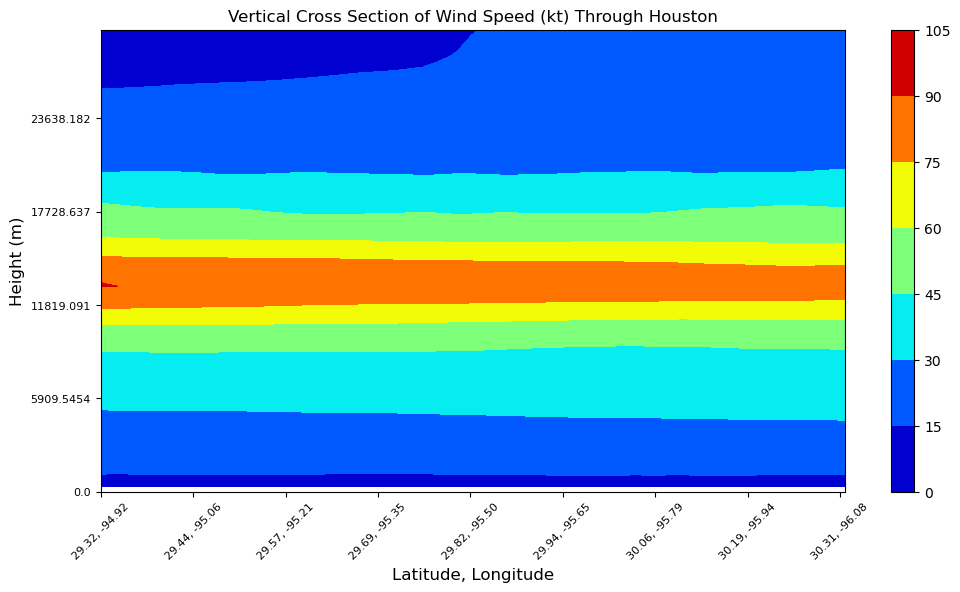

In [4]:
# Extract the model height and wind speed
z = getvar(ncfile, "z")
wspd =  getvar(ncfile, "uvmet_wspd_wdir", units="kt")[0,:]

# Compute the vertical cross-section interpolation.  Also, include the
# lat/lon points along the cross-section.
wspd_cross = vertcross(wspd, z, wrfin=ncfile, start_point=start_point1,
                       end_point=end_point1, latlon=True, meta=True)

# Create the figure
fig = plt.figure(figsize=(12,6))
ax = plt.axes()

# Make the contour plot
wspd_contours = ax.contourf(to_np(wspd_cross), cmap=matplotlib.colormaps['jet'])

# Add the color bar
plt.colorbar(wspd_contours, ax=ax)

# Set the x-ticks to use latitude and longitude labels.
coord_pairs = to_np(wspd_cross.coords["xy_loc"])
x_ticks = np.arange(coord_pairs.shape[0])
x_labels = [pair.latlon_str(fmt="{:.2f}, {:.2f}")
            for pair in to_np(coord_pairs)]
ax.set_xticks(x_ticks[::20])
ax.set_xticklabels(x_labels[::20], rotation=45, fontsize=8)

# Set the y-ticks to be height.
vert_vals = to_np(wspd_cross.coords["vertical"])
v_ticks = np.arange(vert_vals.shape[0])
ax.set_yticks(v_ticks[::20])
ax.set_yticklabels(vert_vals[::20], fontsize=8)

# Set the x-axis and  y-axis labels
ax.set_xlabel("Latitude, Longitude", fontsize=12)
ax.set_ylabel("Height (m)", fontsize=12)

plt.title("Vertical Cross Section of Wind Speed (kt) Through Houston")

plt.show()

#plt.savefig("../../04Visuals/EDA/WindSpeedCrossSection2016_Urban.jpg")
#plt.savefig("../../04Visuals/EDA/WindSpeedCrossSection2017_Urban.jpg")
#plt.savefig("../../04Visuals/EDA/WindSpeedCrossSection207_w16SST_Urban.jpg")

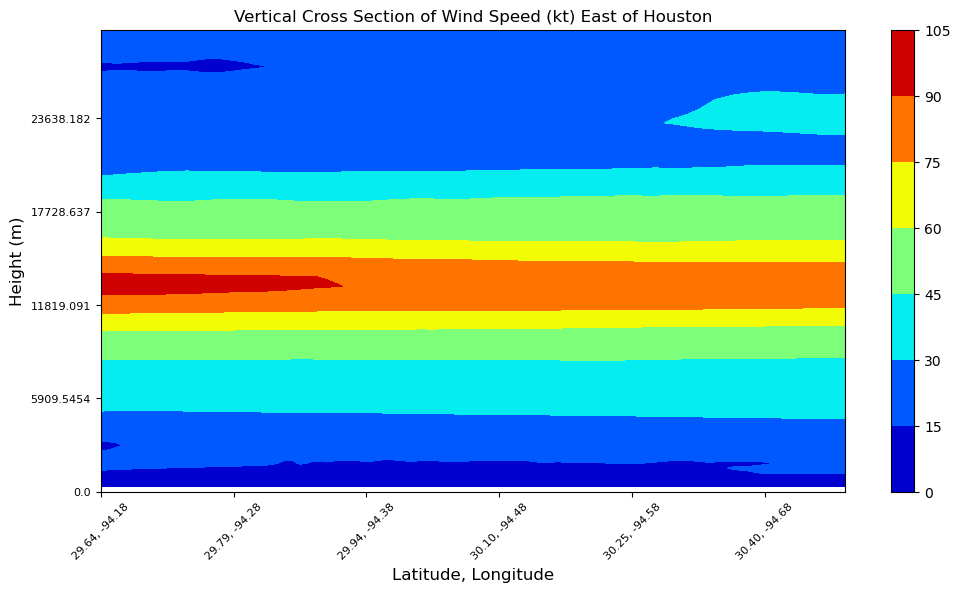

In [4]:
# Extract the model height and wind speed
z = getvar(ncfile, "z")
wspd =  getvar(ncfile, "uvmet_wspd_wdir", units="kt")[0,:]

# Compute the vertical cross-section interpolation.  Also, include the
# lat/lon points along the cross-section.
wspd_cross = vertcross(wspd, z, wrfin=ncfile, start_point=start_point2,
                       end_point=end_point2, latlon=True, meta=True)

# Create the figure
fig = plt.figure(figsize=(12,6))
ax = plt.axes()

# Make the contour plot
wspd_contours = ax.contourf(to_np(wspd_cross), cmap=matplotlib.colormaps['jet'])

# Add the color bar
plt.colorbar(wspd_contours, ax=ax)

# Set the x-ticks to use latitude and longitude labels.
coord_pairs = to_np(wspd_cross.coords["xy_loc"])
x_ticks = np.arange(coord_pairs.shape[0])
x_labels = [pair.latlon_str(fmt="{:.2f}, {:.2f}")
            for pair in to_np(coord_pairs)]
ax.set_xticks(x_ticks[::20])
ax.set_xticklabels(x_labels[::20], rotation=45, fontsize=8)

# Set the y-ticks to be height.
vert_vals = to_np(wspd_cross.coords["vertical"])
v_ticks = np.arange(vert_vals.shape[0])
ax.set_yticks(v_ticks[::20])
ax.set_yticklabels(vert_vals[::20], fontsize=8)

# Set the x-axis and  y-axis labels
ax.set_xlabel("Latitude, Longitude", fontsize=12)
ax.set_ylabel("Height (m)", fontsize=12)

plt.title("Vertical Cross Section of Wind Speed (kt) East of Houston")

plt.show()

#plt.savefig("../../04Visuals/EDA/WindSpeedCrossSection2016_Rural.jpg")
#plt.savefig("../../04Visuals/EDA/WindSpeedCrossSection2017_Rural.jpg")
#plt.savefig("../../04Visuals/EDA/WindSpeedCrossSection2017_w16SST_Rural.jpg")

## Next Visuals

Try to do a similar thing but for cloud cover, seeing where (if anywhere) you see clouds forming in the cross sectional regions

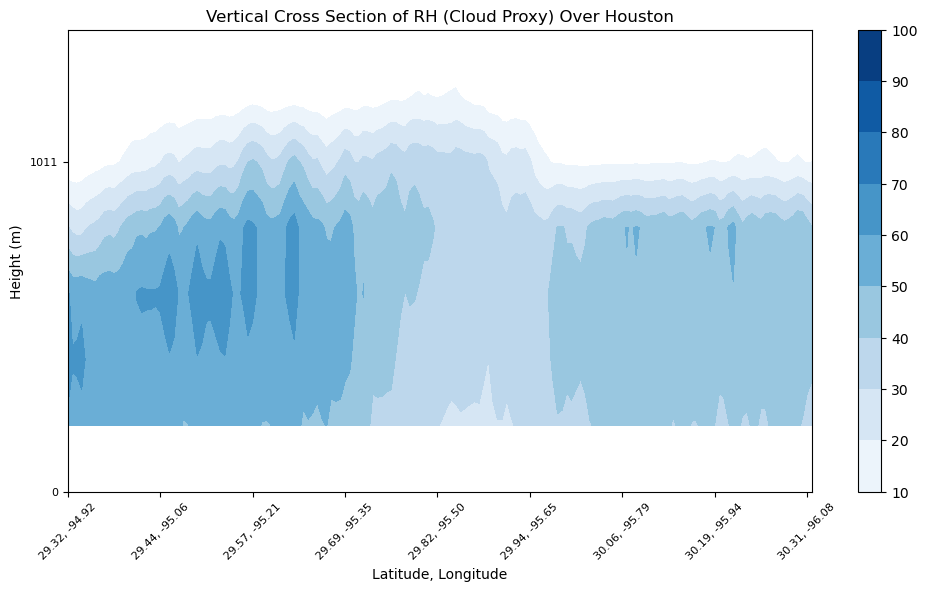

In [9]:
# Extract a single time slice
z = getvar(ncfile, "z", timeidx=0)
rh = getvar(ncfile, "rh", timeidx=0)

# Create vertical cross-section of RH (as a proxy for cloudiness)
rh_cross = vertcross(rh, z, wrfin=ncfile,
                     start_point=start_point1,
                     end_point=end_point1,
                     latlon=True, meta=True)

# Y-axis height
vert_vals = to_np(rh_cross.coords["vertical"])

# Find the index where height <= 1500 m
valid_vert_idx = np.where(vert_vals <= 1500)[0]

# Subset the cross section and vertical coordinate
rh_cross_filtered = rh_cross[valid_vert_idx, :]
vert_vals_filtered = vert_vals[valid_vert_idx]

# Plot only the filtered data
fig = plt.figure(figsize=(12,6))
ax = plt.axes()
contours = ax.contourf(to_np(rh_cross_filtered), levels=np.linspace(10, 100, 10),
                       cmap=matplotlib.colormaps['Blues'])

plt.colorbar(contours, ax=ax)

# X-axis lat/lon
coord_pairs = to_np(rh_cross.coords["xy_loc"])
x_ticks = np.arange(coord_pairs.shape[0])
x_labels = [pair.latlon_str(fmt="{:.2f}, {:.2f}") for pair in coord_pairs]
ax.set_xticks(x_ticks[::20])
ax.set_xticklabels(x_labels[::20], rotation=45, fontsize=8)

# Set y-axis ticks using filtered vertical values
ax.set_yticks(np.arange(len(vert_vals_filtered))[::5])
ax.set_yticklabels(vert_vals_filtered[::5].astype(int), fontsize=8)

ax.set_xlabel("Latitude, Longitude")
ax.set_ylabel("Height (m)")
plt.title("Vertical Cross Section of RH (Cloud Proxy) Over Houston")

#plt.savefig("../../04Visuals/EDA/RHCrossSection2016_Urban.jpg")
#plt.savefig("../../04Visuals/EDA/RHCrossSection2017_Urban.jpg")
#plt.savefig("../../04Visuals/EDA/RHCrossSection2017_w16SST_Urban.jpg")


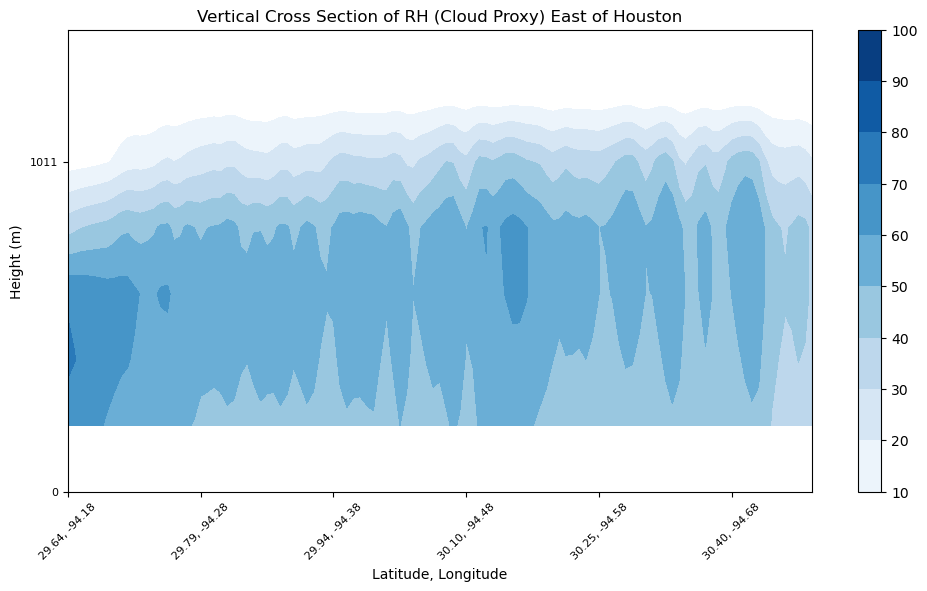

In [10]:
# Extract a single time slice
z = getvar(ncfile, "z", timeidx=0)
rh = getvar(ncfile, "rh", timeidx=0)

# Create vertical cross-section of RH (as a proxy for cloudiness)
rh_cross = vertcross(rh, z, wrfin=ncfile,
                     start_point=start_point2,
                     end_point=end_point2,
                     latlon=True, meta=True)

# Y-axis height
vert_vals = to_np(rh_cross.coords["vertical"])

# Find the index where height <= 1500 m
valid_vert_idx = np.where(vert_vals <= 1500)[0]

# Subset the cross section and vertical coordinate
rh_cross_filtered = rh_cross[valid_vert_idx, :]
vert_vals_filtered = vert_vals[valid_vert_idx]

# Plot only the filtered data
fig = plt.figure(figsize=(12,6))
ax = plt.axes()
contours = ax.contourf(to_np(rh_cross_filtered), levels=np.linspace(10, 100, 10),
                       cmap=matplotlib.colormaps['Blues'])

plt.colorbar(contours, ax=ax)

# X-axis lat/lon
coord_pairs = to_np(rh_cross.coords["xy_loc"])
x_ticks = np.arange(coord_pairs.shape[0])
x_labels = [pair.latlon_str(fmt="{:.2f}, {:.2f}") for pair in coord_pairs]
ax.set_xticks(x_ticks[::20])
ax.set_xticklabels(x_labels[::20], rotation=45, fontsize=8)

# Set y-axis ticks using filtered vertical values
ax.set_yticks(np.arange(len(vert_vals_filtered))[::5])
ax.set_yticklabels(vert_vals_filtered[::5].astype(int), fontsize=8)

ax.set_xlabel("Latitude, Longitude")
ax.set_ylabel("Height (m)")
plt.title("Vertical Cross Section of RH (Cloud Proxy) East of Houston")

#plt.savefig("../../04Visuals/EDA/RHCrossSection2016_Rural.jpg")
#plt.savefig("../../04Visuals/EDA/RHCrossSection2017_Rural.jpg")
#plt.savefig("../../04Visuals/EDA/RHCrossSection2017_w16SST_Rural.jpg")

## Plotting sea level pressure

This seems to be showing a signal consistent with a sea breeze, but would be good to check this somehow

https://wrf-python.readthedocs.io/en/latest/plot.html#id1

C:\Users\rpkamakura\AppData\Local\Temp\ipykernel_45492\2841776162.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bm.contourf(x, y, to_np(smooth_slp), 10, cmap=get_cmap("jet"))


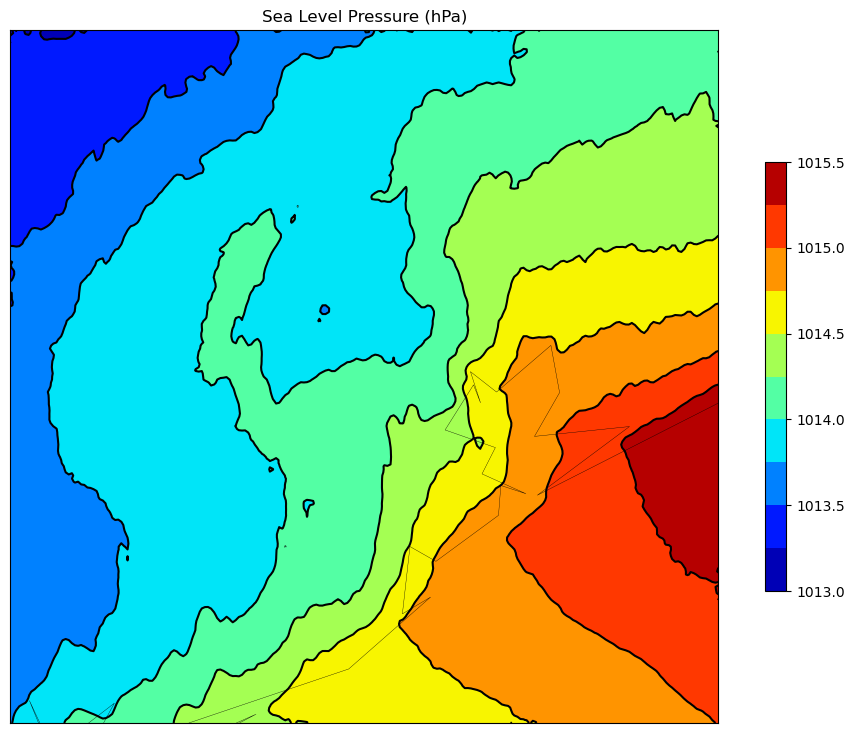

In [11]:
# Open the NetCDF file
# Get the sea level pressure
slp = getvar(ncfile, "slp")

# Smooth the sea level pressure since it tends to be noisy near the
# mountains
smooth_slp = smooth2d(slp, 3, cenweight=4)

# Get the latitude and longitude points
lats, lons = latlon_coords(slp)

# Get the basemap object
bm = get_basemap(slp)

# Create a figure
fig = plt.figure(figsize=(12,9))

# Add geographic outlines
bm.drawcoastlines(linewidth=0.25)
bm.drawstates(linewidth=0.25)
bm.drawcountries(linewidth=0.25)

# Convert the lats and lons to x and y.  Make sure you convert the lats and
# lons to numpy arrays via to_np, or basemap crashes with an undefined
# RuntimeError.
x, y = bm(to_np(lons), to_np(lats))

# Draw the contours and filled contours
bm.contour(x, y, to_np(smooth_slp), 10, colors="black")
bm.contourf(x, y, to_np(smooth_slp), 10, cmap=get_cmap("jet"))

# Add a color bar
plt.colorbar(shrink=.62)

plt.title("Sea Level Pressure (hPa)")

#plt.show()

#plt.savefig("../../04Visuals/EDA/SeaLevelPressure2016.jpg")
#plt.savefig("../../04Visuals/EDA/SeaLevelPressure2017.jpg")
plt.savefig("../../04Visuals/EDA/SeaLevelPressure2017_w16SST.jpg")